# Assignment 2: (Unsupervised Learning for Cardiac Health Risk Assessment using Clustering)
---
---

## Task 1: Understanding the Dataset (1 Mark)
---

### a.Import useful Libraries:

### Importing essential libraries
This cell loads core Python libraries used for data manipulation and numerical computations.

In [167]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.mixture import GaussianMixture
import math

### Loading the dataset
Here we load the modified heart failure dataset into a pandas DataFrame for further analysis.

In [168]:
# Load the dataset
df = pd.read_csv('./Datasets/Modified_Heart_failure_data.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (299, 13)

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0      0.0                     582.0       0.0               20.0   
1  55.0      0.0                    7861.0       0.0               38.0   
2  65.0      NaN                     146.0       0.0               20.0   
3  50.0      1.0                     111.0       0.0               20.0   
4  65.0      1.0                     160.0       1.0               20.0   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                  1.0  265000.00               1.9         130.0  1.0   
1                  0.0  263358.03               1.1         136.0  1.0   
2                  0.0  162000.00               1.3         129.0  1.0   
3                  0.0  210000.00               NaN         137.0  1.0   
4                  0.0  327000.00               2.7         116.0  0.0   

   smoking  time  patient_id  
0      0.0   4.0           0  
1 

### Inspecting data structure
This cell prints data types and missing values to understand dataset composition.

In [169]:
print("\nData Types and Missing Values:")
print(df.info())


Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       270 non-null    float64
 1   anaemia                   270 non-null    float64
 2   creatinine_phosphokinase  270 non-null    float64
 3   diabetes                  270 non-null    float64
 4   ejection_fraction         270 non-null    float64
 5   high_blood_pressure       270 non-null    float64
 6   platelets                 270 non-null    float64
 7   serum_creatinine          270 non-null    float64
 8   serum_sodium              270 non-null    float64
 9   sex                       270 non-null    float64
 10  smoking                   270 non-null    float64
 11  time                      270 non-null    float64
 12  patient_id                299 non-null    int64  
dtypes: float64(12), int64(1)
memory u

### Checking missing values explicitly
Provides a direct count of missing entries per column.

In [170]:
# Check for missing values; from the above df.info() we get this info, but to explicitly show missing values:
df.isnull().sum()

age                         29
anaemia                     29
creatinine_phosphokinase    29
diabetes                    29
ejection_fraction           29
high_blood_pressure         29
platelets                   29
serum_creatinine            29
serum_sodium                29
sex                         29
smoking                     29
time                        29
patient_id                   0
dtype: int64

### Summary statistics overview
Displays summary statistics for continuous features.

In [171]:

print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  270.000000  270.000000                270.000000  270.000000   
mean    60.934570    0.437037                574.266667    0.411111   
std     11.838766    0.496941                958.532760    0.492949   
min     40.000000    0.000000                 23.000000    0.000000   
25%     52.000000    0.000000                119.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         270.000000           270.000000     270.000000   
mean           37.622222             0.355556  261522.410185   
std            11.715885             0.479570   97633.259068   
min            14.000000             0.000000   25100.000000   
25%            30.0

#### Box Plot Visualization for all features
---
- Features such as creatinine_phosphokinase, platelets and serum_sodium have high number of Outliers
- Platelets have a very High range of values with a range of 0 to 800000 compared to other continuous features
- Binary features are diabetes, anaemia, high_blood_pressure, smoking and sex. Rest are Continuous Features

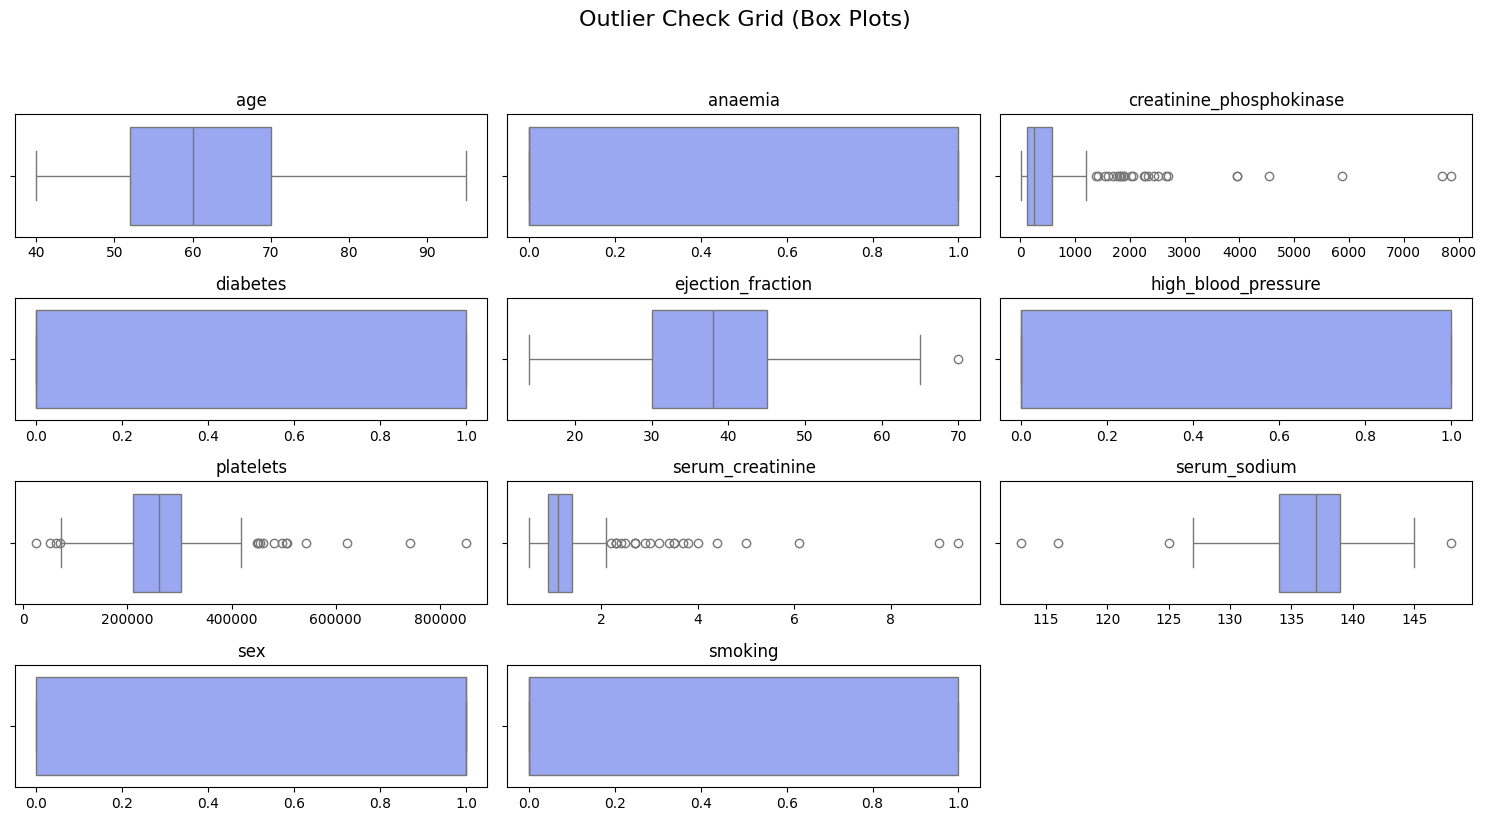

In [172]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [item for item in numeric_cols if item not in ["patient_id", "time"]]
num_plots = len(numeric_cols)
cols = 3
title = "Outlier Check Grid (Box Plots)"
rows = math.ceil(num_plots / cols)
fig, axes = plt.subplots(
        rows, cols, 
        figsize=(5 * cols, 2 * rows)
)

axes = axes.flatten() if rows > 1 else np.array([axes])

for i, col in enumerate(numeric_cols):
        # Use dropna() to plot only the non-null values
        sns.boxplot(x=df[col].dropna(), orient='h', ax=axes[i], color='#8c9eff')
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel("") 

for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])
        
# 6. Final Figure adjustments
fig.suptitle(title, fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Correlation heatmap generation

- From Heatmap, we can deduce that high correlated pairs are {serum_sodium, ejection_fraction} and {smoking, sex}

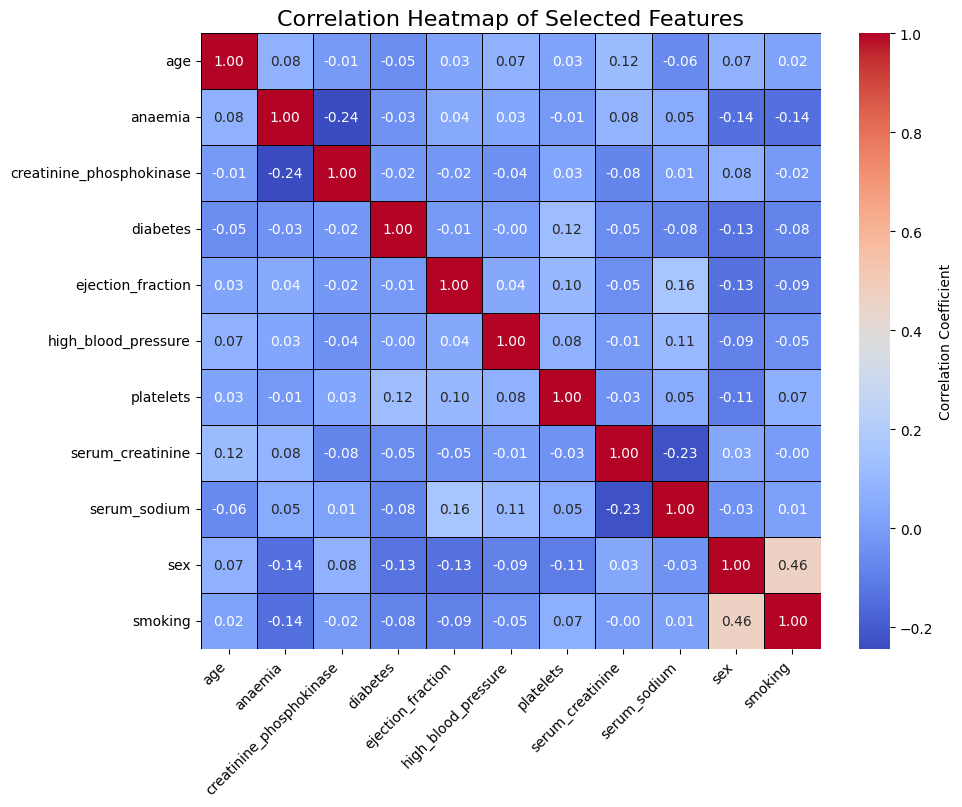

In [173]:
# Heat Map to show correlations
df_corr = df[numeric_cols].copy().corr()

plt.figure(figsize=(10, 8)) 
    
sns.heatmap(
    df_corr,
    annot=True,              
    fmt=".2f",              
    cmap='coolwarm',         
    linewidths=0.5,          
    linecolor='black',       
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Selected Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

## Task 2: Data Pre-processing (2 Marks)
---

### Imputation of missing values
Handles missing binary and continuous features.

- Binary Data are imputed with mode values so the NULL are replaced with the values of higher frequencies
- COntinuous Data are imputed with median values to have values that represent the 50th Percentile of the data.

In [174]:
#Imputattion for Binary and Continuous Features
binary_cols = [col for col in df[numeric_cols].columns if set(df[col].dropna().unique()).issubset({0, 1})]
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

df[continuous_cols] = df[continuous_cols].fillna(df[continuous_cols].median())
df[binary_cols] = df[binary_cols].fillna(df[binary_cols].mode().iloc[0])

### Feature scaling step
Applying Robust Scaling method

- Scaling is applied to continuous data and not to binary data

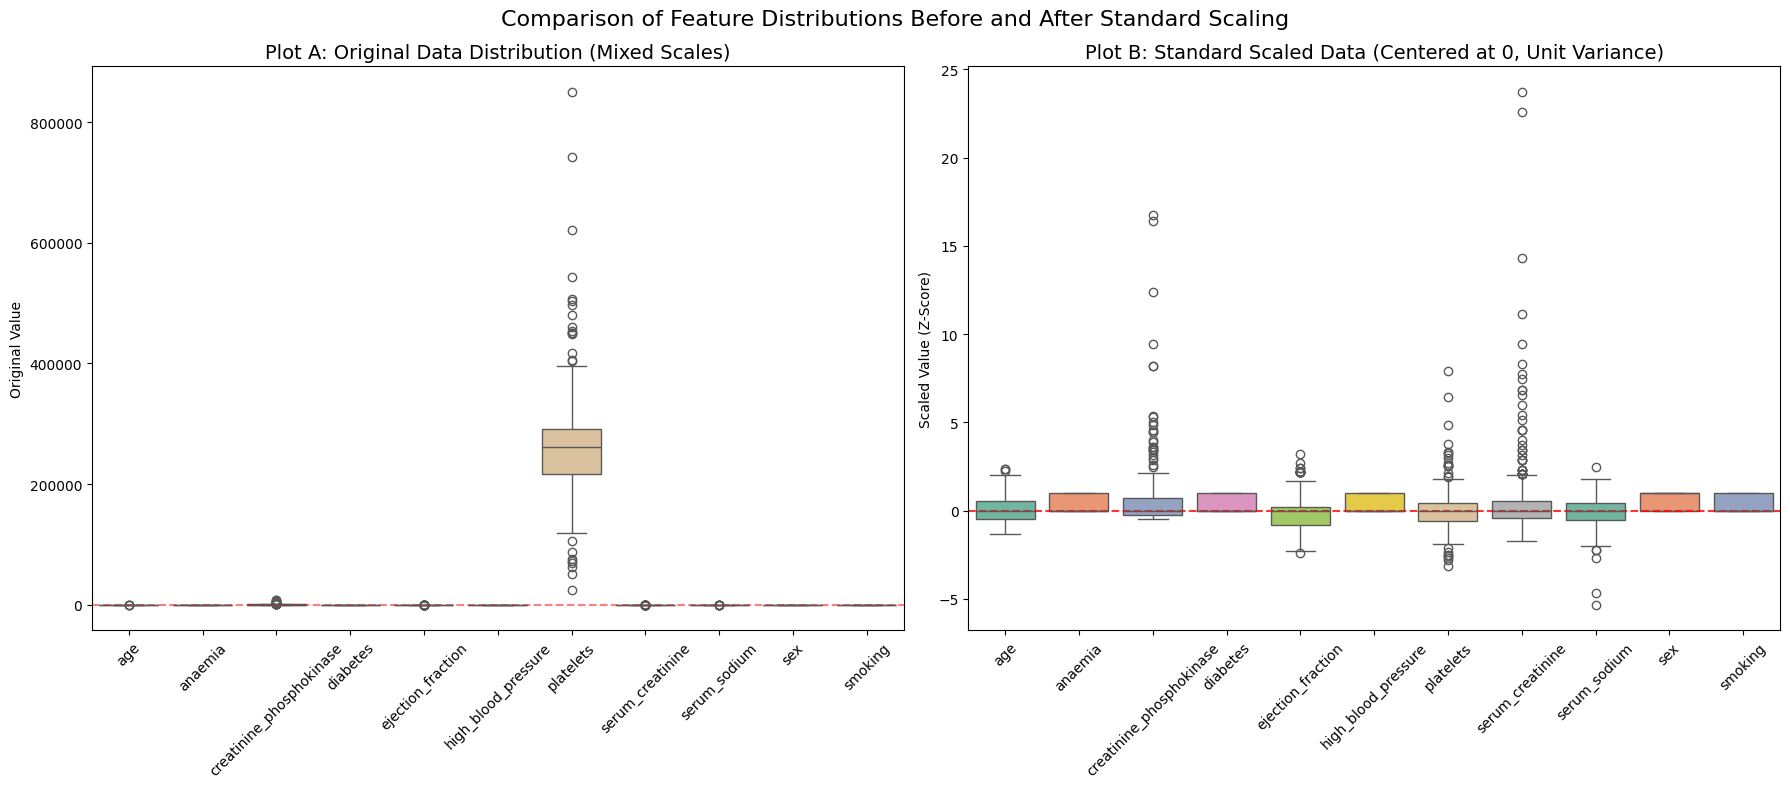

In [ ]:
# With the Heat_map above, I can see that there are no strong correlations between features, so I can proceed without dropping any features for scaling
df_scaled_rob = df[numeric_cols].copy()
scaler_full = RobustScaler()
df_scaled_rob[continuous_cols] = scaler_full.fit_transform(df[continuous_cols])

# Set up the figure for two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before Plot
sns.boxplot(
    data=X,
    ax=axes[0], 
    palette='Set2'
)
axes[0].set_title('Plot A: Original Data Distribution (Mixed Scales)', fontsize=14)
axes[0].set_ylabel('Original Value')
axes[0].tick_params(axis='x', rotation=45) # Rotate labels for readability
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# After Plot
sns.boxplot(
    data=df_scaled_rob,
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('Plot B: Standard Scaled Data (Centered at 0, Unit Variance)', fontsize=14)
axes[1].set_ylabel('Scaled Value (Z-Score)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.8)

plt.suptitle('Comparison of Feature Distributions Before and After Standard Scaling', fontsize=16)
plt.tight_layout()
plt.show()

### Task 3: Cluster Evaluation (5 marks)
---

#### [1] K-Means Clustering

In [ ]:
# K-Means Clustering and Evaluation Function

def k_means_evaluation(df, df_selected):

    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    results = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_temp.fit(df_selected)
        labels = kmeans_temp.labels_
        inertias.append(kmeans_temp.inertia_)
        silhouette_scores.append(silhouette_score(df_selected, kmeans_temp.labels_))
        davies_bouldin_scores.append(davies_bouldin_score(df_selected, labels))
        results.append({
            'k': k,
            'inertia': kmeans_temp.inertia_,
            'silhouette_score': silhouette_score(df_selected, kmeans_temp.labels_),
            'davies_bouldin_score': davies_bouldin_score(df_selected, labels)
        })

    # Plot elbow + silhouette
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax1.set_ylabel('Within-Cluster Sum of Squares', fontsize=11)
    ax1.set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3)

    # Silhouette plot
    ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax2.set_ylabel('Silhouette Score', fontsize=11)
    ax2.set_title('Silhouette Score vs k', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('3_kmeans_optimal_k_selected.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print numeric results
    print("\n K-Means Evaluation Values (Using Selected Features)")
    print("-" * 50)
    print(pd.DataFrame(results))

#### Exploring K means clustering using unscaled data

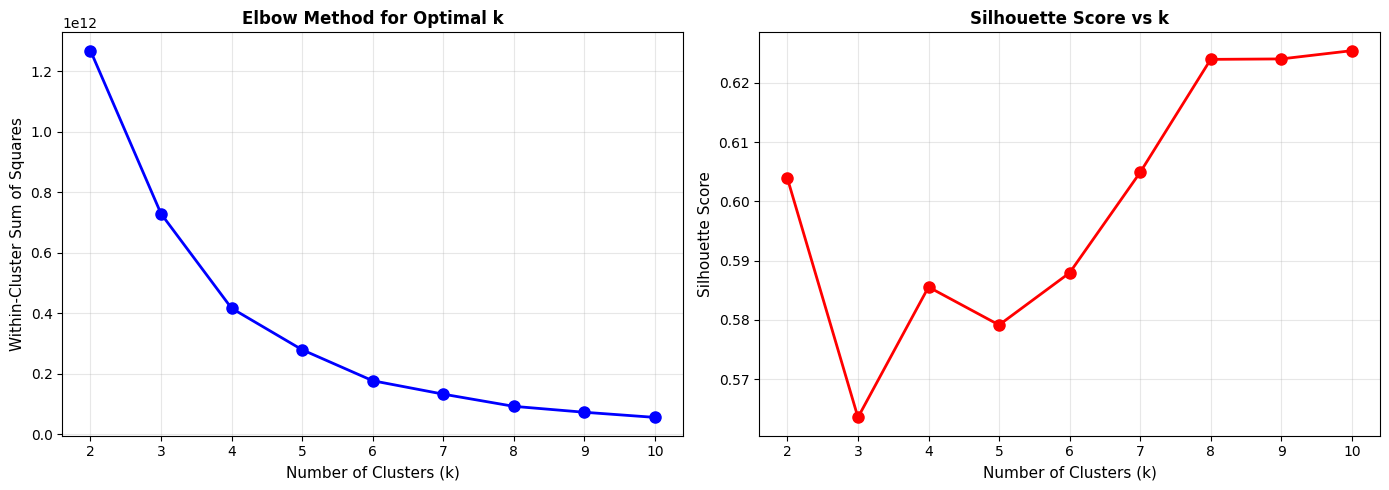


 K-Means Evaluation Values (Using Selected Features)
--------------------------------------------------
    k       inertia  silhouette_score  davies_bouldin_score
0   2  1.268181e+12          0.603857              0.647360
1   3  7.289496e+11          0.563550              0.560442
2   4  4.164179e+11          0.585543              0.469745
3   5  2.792405e+11          0.579140              0.488103
4   6  1.768128e+11          0.587937              0.461010
5   7  1.324693e+11          0.604878              0.456511
6   8  9.215843e+10          0.623948              0.424798
7   9  7.259768e+10          0.624024              0.464065
8  10  5.560163e+10          0.625416              0.467160


In [ ]:
# Selected all features and with unscaled data for Initial Analysis

selected_features = [
    'age',
    'creatinine_phosphokinase',
    'serum_creatinine',
    'ejection_fraction',
    'platelets',
    'serum_sodium',
    'high_blood_pressure',
    'anaemia',
    'diabetes',
    'sex',
    'smoking'
]

df_selected = df[selected_features]
k_means_evaluation(df, df_selected)

#### Exploring K means clustering using scaled data

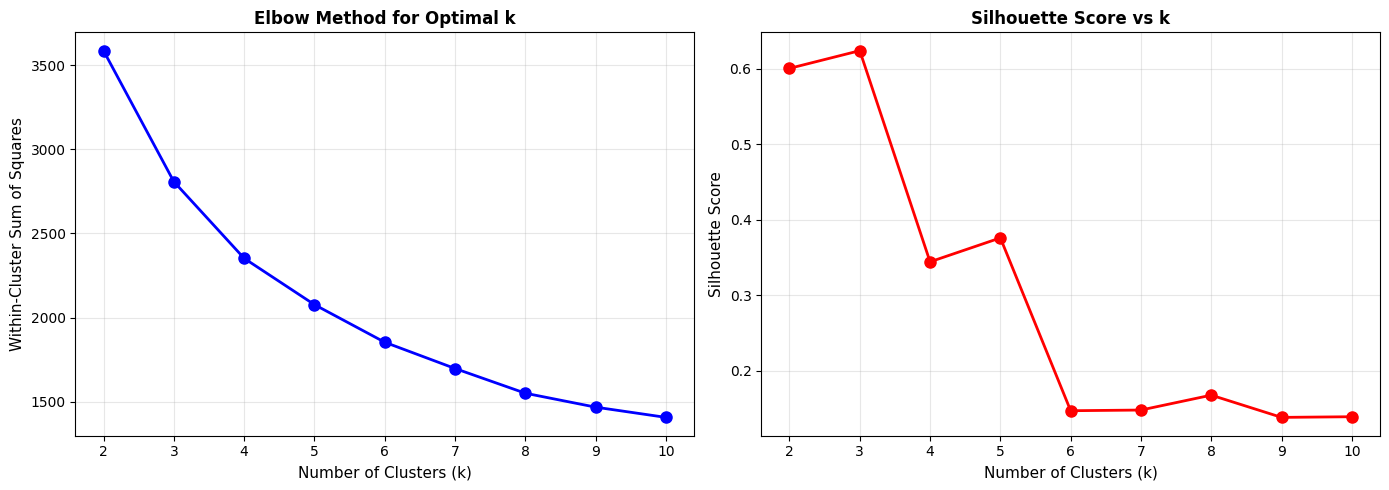


 K-Means Evaluation Values (Using Selected Features)
--------------------------------------------------
    k      inertia  silhouette_score  davies_bouldin_score
0   2  3585.645007          0.600238              0.835516
1   3  2807.604191          0.623678              0.707835
2   4  2352.069882          0.344205              1.000821
3   5  2076.777863          0.375863              0.874786
4   6  1853.392486          0.147118              1.291392
5   7  1697.327056          0.148013              1.326148
6   8  1550.484716          0.167731              1.236927
7   9  1467.676079          0.138296              1.383421
8  10  1406.906141          0.139165              1.341387


In [216]:
# All features and feature Scaling included for Analysis

selected_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'serum_creatinine',
    'platelets',
    'serum_sodium',
    'high_blood_pressure',
    'anaemia',
    'diabetes',
    'sex',
    'smoking'
]

df_scaled_selected = df_scaled_rob[selected_features]
k_means_evaluation(df, df_scaled_selected)

#### Exploring K means clustering using scaled data and selective features

- The features are selected on ther basis of their correlation magnitude.
- The paris that we found initially were {serum_sodium, ejection_fraction} and {smoking, sex}
- Selecting one features from each pair to represent their values in the clusters

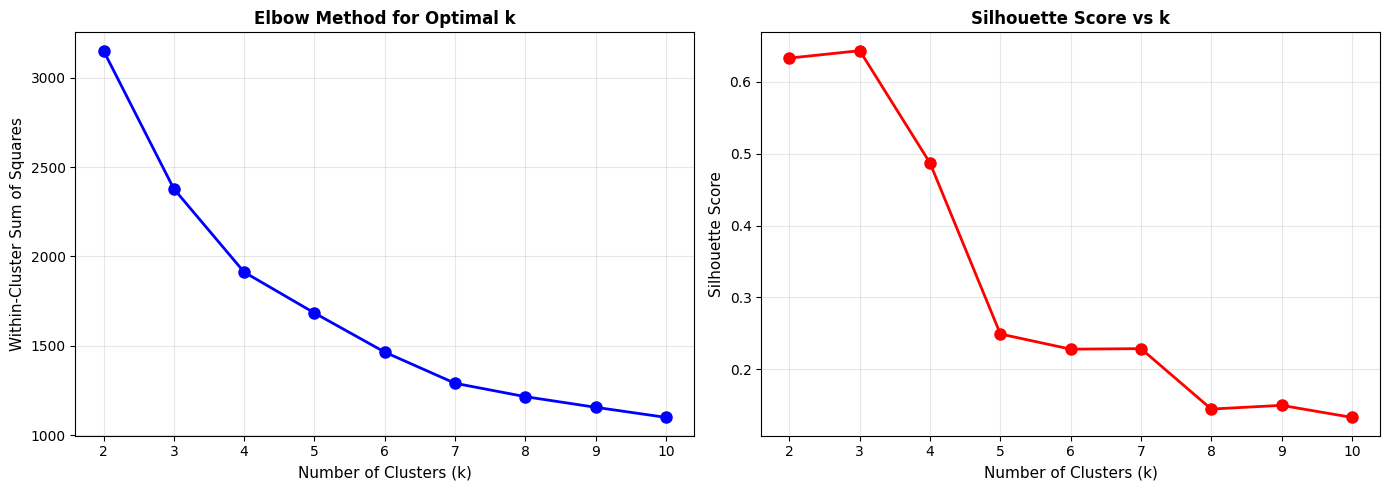


 K-Means Evaluation Values (Using Selected Features)
--------------------------------------------------
    k      inertia  silhouette_score  davies_bouldin_score
0   2  3152.245474          0.633015              0.788867
1   3  2378.689106          0.643337              0.701553
2   4  1912.209403          0.486884              0.769940
3   5  1683.354630          0.249150              1.187324
4   6  1464.190084          0.228047              1.105777
5   7  1289.694667          0.228763              1.060937
6   8  1214.746528          0.144694              1.277150
7   9  1155.202639          0.149878              1.210017
8  10  1098.683587          0.133126              1.285105


In [217]:
# Feature Selection based on Correlation for K-Means
# Removed ejection_fraction and sex features due to high correlation with serum_sodium and smoking resp.

selected_features = [
    'age',
    'creatinine_phosphokinase',
    'high_blood_pressure',
    'anaemia',
    'diabetes',
    'platelets',
    'smoking',
    'serum_sodium',
    'serum_creatinine'
]

df_scaled_selected = df_scaled_rob[selected_features]

k_means_evaluation(df, df_scaled_selected)


#### K means Clustering using optimal K for Visualization 

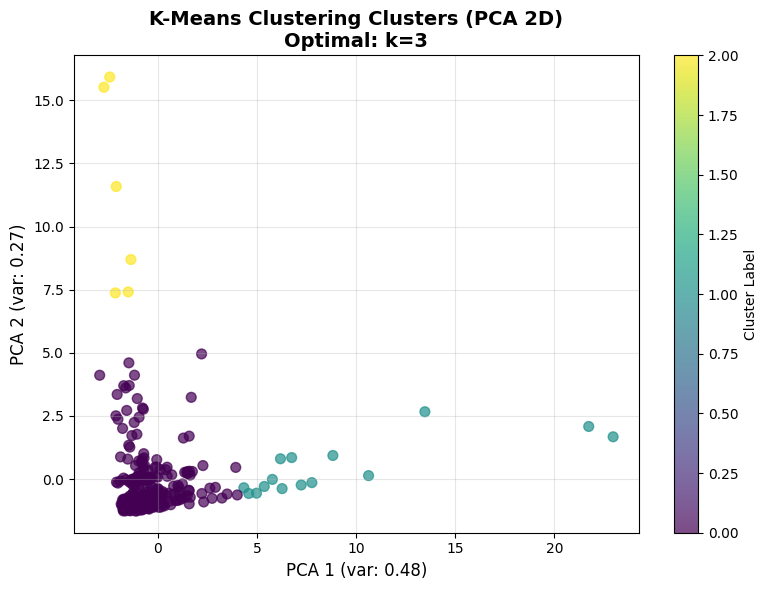

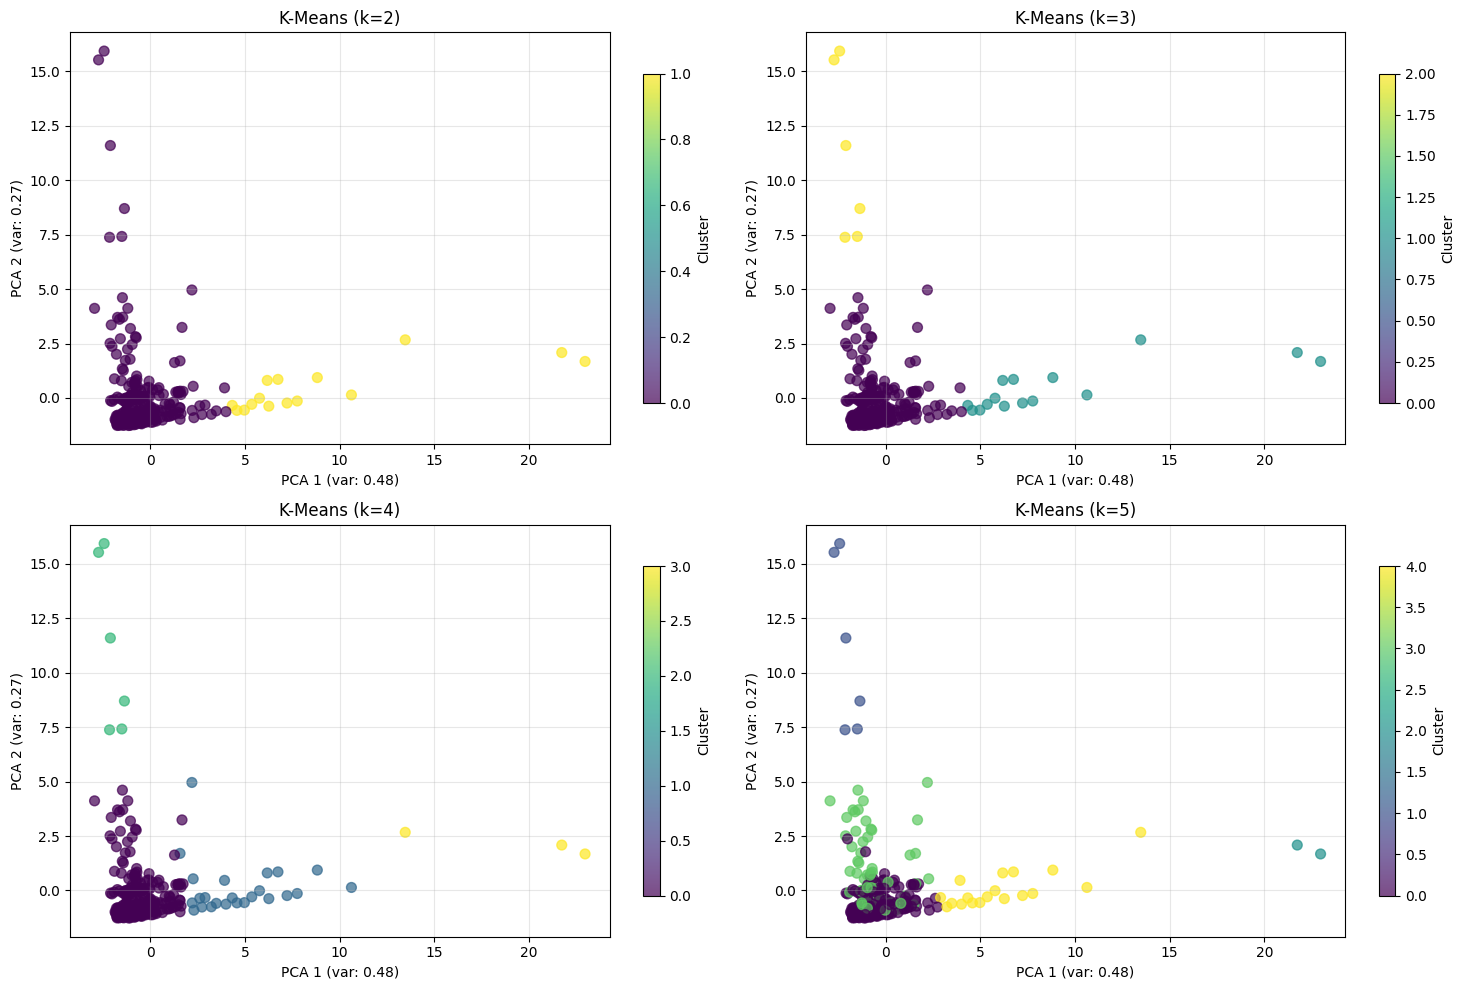

In [237]:
# From above I can see that k=3 is optimal, while from elbow curve, I can deduce that k=4 is also a good choice.
# I will go with k=3 for final visualization.
optimal_k_kmeans = 3

# Perform K-Means with optimal k
kmeans_opt = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
kmeans_labels_opt = kmeans_opt.fit_predict(df_scaled_selected)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled_selected)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels_opt, cmap='viridis', s=50, alpha=0.7)
plt.title(f'K-Means Clustering Clusters (PCA 2D)\nOptimal: k={optimal_k_kmeans}', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA 1 (var: {pca.explained_variance_ratio_[0]:.2f})', fontsize=12)
plt.ylabel(f'PCA 2 (var: {pca.explained_variance_ratio_[1]:.2f})', fontsize=12)
plt.colorbar(scatter, label='Cluster Label')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

chosen_k_range = range(2, 6) 
plt.figure(figsize=(15, 10))

for i, k in enumerate(chosen_k_range):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(df_scaled_selected)
    
    plt.subplot(2, 2, i+1)  # 2x2 grid for 4 plots
    scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_temp, cmap='viridis', s=50, alpha=0.7)
    plt.title(f'K-Means (k={k})', fontsize=12)
    plt.xlabel(f'PCA 1 (var: {pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'PCA 2 (var: {pca.explained_variance_ratio_[1]:.2f})')
    plt.colorbar(scatter, label='Cluster', shrink=0.8)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Cluster sizes and distribution of patients:

In [238]:
for k in range(0,3):
    count = np.sum(kmeans_labels_opt == k)
    print(f"Cluster {k}: {count} patients ({count / len(kmeans_labels_opt) * 100:.2f}%)" )

Cluster 0: 278 patients (92.98%)
Cluster 1: 15 patients (5.02%)
Cluster 2: 6 patients (2.01%)


### [2] Hierarchical CLustering and Dendogram for Visualization
---

### Hierarchical clustering dendrograms
Dendrograms plots using different linkage methods for comparison.

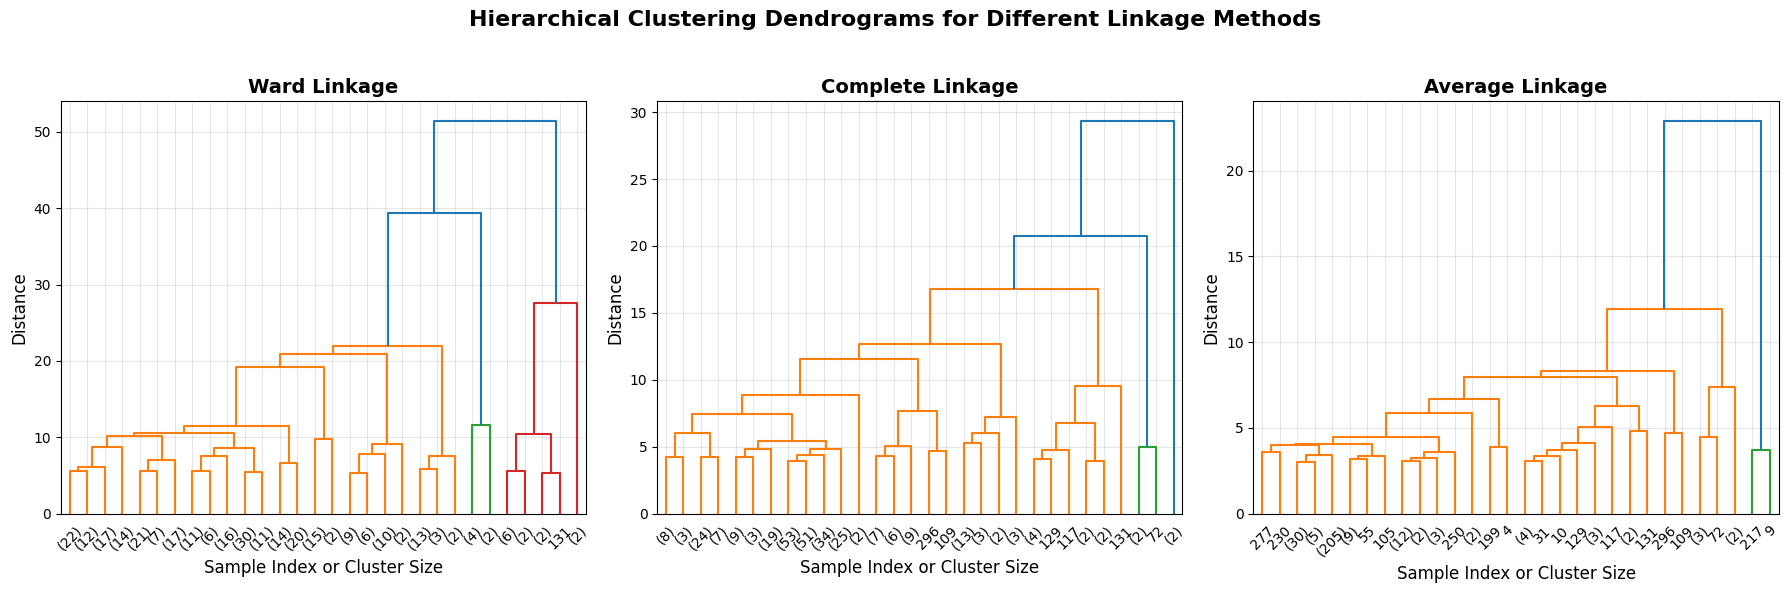

In [ ]:
# Hierarchical Clustering Dendrograms for Different Linkage Methods, I chose 3 linkage methods to compare

linkage_methods = ['ward', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 
for i, method in enumerate(linkage_methods):
    linked = linkage(df_scaled_selected, method=method)
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True, truncate_mode='lastp', p=30, ax=axes[i])
    axes[i].set_title(f'{method.capitalize()} Linkage', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Sample Index or Cluster Size', fontsize=12)
    axes[i].set_ylabel('Distance', fontsize=12)
    axes[i].grid(alpha=0.3)

fig.suptitle('Hierarchical Clustering Dendrograms for Different Linkage Methods', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Result output along with Sihouette Scores and Davies Bouldin scores

### Hierarchical clustering evaluation
Evaluate clustering performance for different k values.

In [220]:
# Hierachical Clustering Evaluation and optimal k comparisons

k_range = range(2, 11) # k from 2 to 10

results_data = []

# Loop through Linkage Methods and Calculate Scores
for method in linkage_methods:
    
    for k in k_range:
        
        agg_model = AgglomerativeClustering(
            n_clusters=k,
            linkage=method
        )
        
        clusters = agg_model.fit_predict(df_scaled_selected)
        sil_score = silhouette_score(df_scaled_selected, clusters)
        davies_bouldin = davies_bouldin_score(df_scaled_selected, clusters)

        # Append results as a dictionary to the list
        results_data.append({
            'Linkage Method': method.capitalize(),
            'k': k,
            'Silhouette Score': sil_score,
            'Davies-Bouldin Index': davies_bouldin
        })

### Printing silhouette scores

In [222]:
# Output results of Silhouette 

results_df = pd.DataFrame(results_data)

# 4. Find the Optimal Parameters
optimal_row = results_df.loc[results_df['Silhouette Score'].idxmax()]

# --- Display Results ---

print("Hierarchical Clustering Evaluation Values (DataFrame Format):")
print("-" * 50)
# Print the full results DataFrame
print(results_df)
print("-" * 50)

Hierarchical Clustering Evaluation Values (DataFrame Format):
--------------------------------------------------
   Linkage Method   k  Silhouette Score  Davies-Bouldin Index
0            Ward   2          0.649795              0.746744
1            Ward   3          0.656934              0.671054
2            Ward   4          0.596083              0.538926
3            Ward   5          0.357030              0.771273
4            Ward   6          0.293224              0.967396
5            Ward   7          0.290287              0.981069
6            Ward   8          0.294332              0.906218
7            Ward   9          0.140467              1.156969
8            Ward  10          0.110231              1.430153
9        Complete   2          0.818563              0.202979
10       Complete   3          0.737665              0.285486
11       Complete   4          0.590419              0.491254
12       Complete   5          0.415117              0.692118
13       Complete  

### Sihouette Score mapping
---

#### Importing matplotlib for visualizations
Plot silhouette and clustering results.

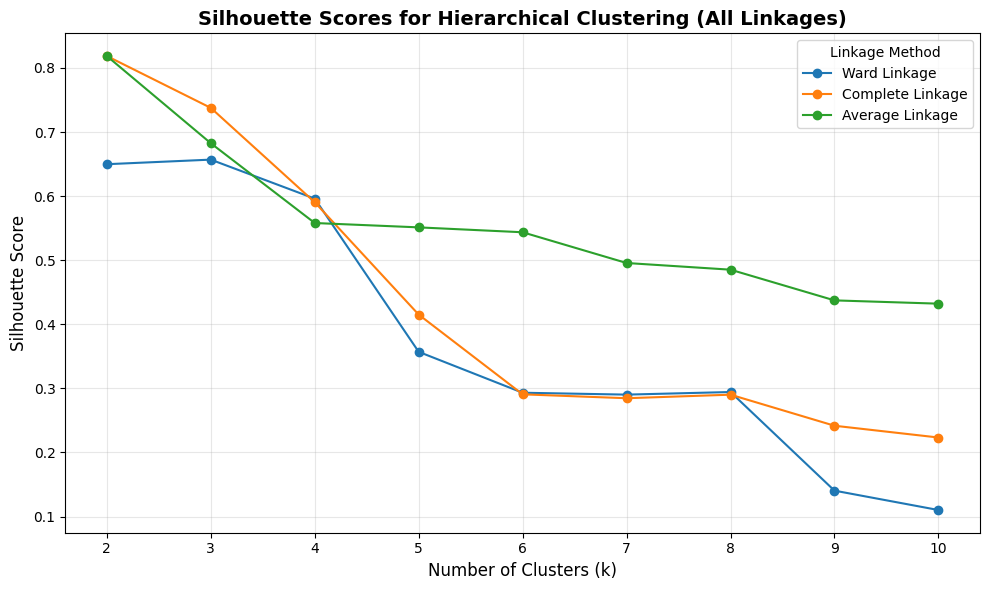

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot each linkage method as a separate line
for method in linkage_methods:
    method_data = results_df[results_df['Linkage Method'] == method.capitalize()]
    plt.plot(method_data['k'], method_data['Silhouette Score'], marker='o', label=f'{method.capitalize()} Linkage')

# Customize the plot
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Scores for Hierarchical Clustering (All Linkages)', fontsize=14, fontweight='bold')
plt.legend(title='Linkage Method')
plt.grid(alpha=0.3)
plt.xticks(k_range) 
plt.tight_layout()

# Save and show the plot
plt.savefig('hierarchical_silhouette_all_linkages.png', dpi=300, bbox_inches='tight')
plt.show()



### Visualization of clusters for Hierarchical Clustering
---

#### Plotting hierarchical clustering results
Visualizes clusters for the selected linkage and optimal k.

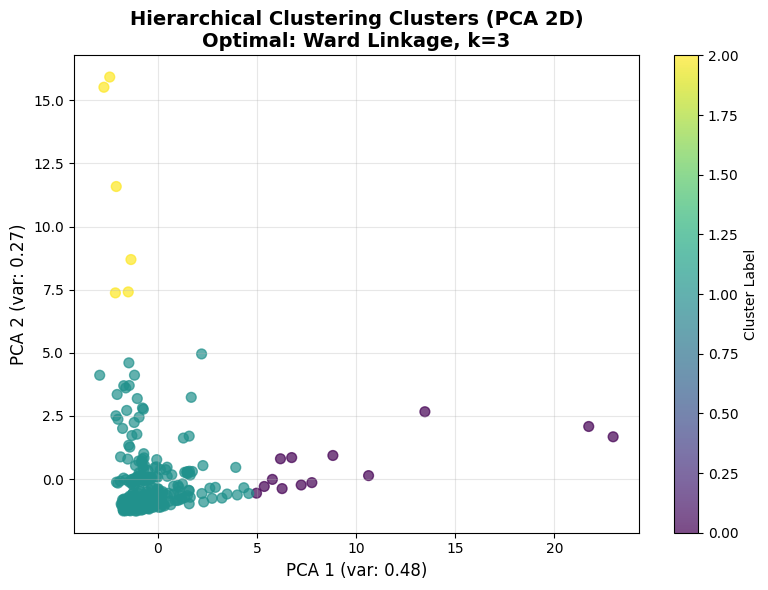

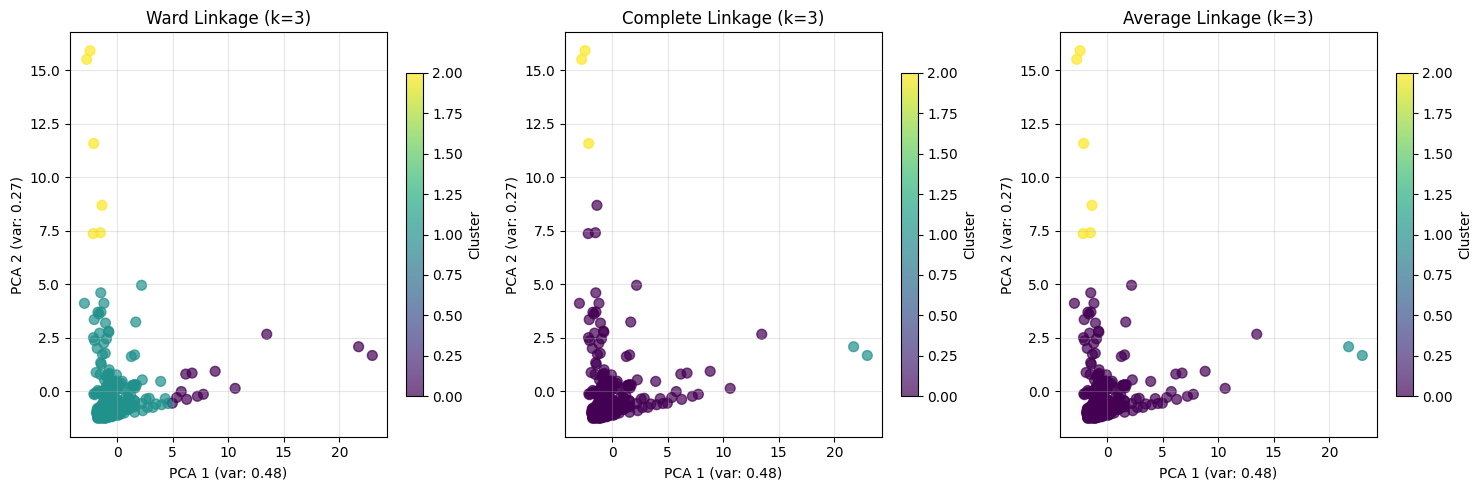

In [239]:
# Visualizations for Optimal Linkage Method and k

optimal_method = "ward"
optimal_k = 3

# Perform clustering with optimal parameters
agg_opt = AgglomerativeClustering(n_clusters=optimal_k, linkage=optimal_method)
clusters_opt = agg_opt.fit_predict(df_scaled_selected)
agg_opt_label = agg_opt.labels_

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled_selected)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_opt, cmap='viridis', s=50, alpha=0.7)
plt.title(f'Hierarchical Clustering Clusters (PCA 2D)\nOptimal: {optimal_method.capitalize()} Linkage, k={optimal_k}', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA 1 (var: {pca.explained_variance_ratio_[0]:.2f})', fontsize=12)
plt.ylabel(f'PCA 2 (var: {pca.explained_variance_ratio_[1]:.2f})', fontsize=12)
plt.colorbar(scatter, label='Cluster Label')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Choosen k = 3
chosen_k = 3  
plt.figure(figsize=(15, 5))

for i, method in enumerate(linkage_methods):
    agg_temp = AgglomerativeClustering(n_clusters=chosen_k, linkage=method)
    clusters_temp = agg_temp.fit_predict(df_scaled_selected)
    
    plt.subplot(1, 3, i+1)
    scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_temp, cmap='viridis', s=50, alpha=0.7)
    plt.title(f'{method.capitalize()} Linkage (k={chosen_k})', fontsize=12)
    plt.xlabel(f'PCA 1 (var: {pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'PCA 2 (var: {pca.explained_variance_ratio_[1]:.2f})')
    plt.colorbar(scatter, label='Cluster', shrink=0.8)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_clusters_pca_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()


#### Cluster size and patient distribution percentage:

In [240]:

for h in range(0,3):
    count = np.sum(agg_opt_label == h)
    print(f"Cluster {h}: {count} patients ({count / len(agg_opt_label) * 100:.2f}%)" )

Cluster 0: 13 patients (4.35%)
Cluster 1: 280 patients (93.65%)
Cluster 2: 6 patients (2.01%)


### Interpretation and Usefulness (2 Mark)
---

#### Interpretation:

This Assignment aims at Cardiac Health Risk Assessment with a dataset of 299 rows [Patients] and 13 columns [Features]. From the inital assessment, I can see that there is approx. 9.7% data missing from each column. For a more robust approach and meaningful insights, I did some Imputation and Feature scaling as observed in the Data Pre-processing section of this notebook.

Based on the $\text{K}=3$ results:

* **Hierarchical Clustering (Ward)** has the better **Silhouette Score** ($0.6569$) compared to **K-Means** ($0.6433$), suggesting the clusters it formed are **more cohesive** (tight) and **separated** from their neighbors.
* **Hierarchical Clustering (Ward)** also has the better **Davies-Bouldin Index** ($0.6711$) compared to **K-Means** ($0.7016$), indicating it achieved slightly **less average overlap** between its clusters.
* Both methods show **good clustering quality** (Silhouette scores well above $0.5$ and DBI scores below $1.0$). The **Hierarchical** solution appears marginally superior due to the slightly higher Silhouette Score and a lower Davies-Bouldin Index.

Note that for Hierarchical clustering, I have used three linkage methods namely Ward, Complete and Average which provide different Accuracies but it is clear from the clustering plot that with other linkage methods the clusters are either including points that are too far or overlapping more with each other. Thus Ward linkage with k = 3 has been chosen for comparison between Hierarchical and K-Means clustering.

Below is the clustering plots and Score comparison of both methods, which were plotted above, side by side for better understanding.


<div style="display: flex;">
    <div style="width: 50%; padding: 5px; box-sizing: border-box;">
        <img src="./Images/K-means.png" alt="Image 1" style="width: 100%;"/>
        <p style="text-align: center;">Figure A: K-Means Clustering</p>
    </div>
    <div style="width: 50%; padding: 5px; box-sizing: border-box;">
        <img src="./Images/Hierarchical.png" alt="Image 2" style="width: 100%;"/>
        <p style="text-align: center;">Figure B: Hierarchical Clustering</p>
    </div>
</div>

### Comparison of Clustering Results at K=3

| Metric | K-Means (K=3) | Hierarchical (Ward, K=3) | Interpretation |
| :--- | :---: | :---: | :--- |
| **Inertia (WCSS)** | $2378.689106$ | N/A | Measures cluster **tightness**. Lower is better. |
| **Silhouette Score** | $0.643337$ | **$0.6569$** | Measures **cohesion and separation**. Closer to +1 is better. |
| **Davies-Bouldin Index** | **$0.7016$** | $0.6711$ | Measures **inter-cluster similarity/overlap**. Lower is better. |

***


#### Usefulness:

Unsupervised learning Approach helped us to group the data into multiple clusters further providing more information and significance of a group of data

Based on this the usefulness of such an approach can be seen as:

- Discovery: Revealiing new or unrecognised Cardiac risk groups
- Risk classification: Well separation of patients into risk levels for better intervention.
- Tailored treatment planning: Different groups now can have personalized treatment plans for better prevention.
- Anomaly Detection: Will be able to detect patients that don't fit the normal cluster patterns and provides future scopr for research.
- Feature Selection: Helps Researchers understand more clearly about the importance of certain features and may help with future predictive models for more specific focuses on these important groups.